# **Amazon Product Data Analysis**
## **Dataset Source & Link:**
#### - Source: Amazon product dataset (CSV file)
#### - Link: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset
## **Problem Statement:**  
### The project Aims to analyze Amazon product data to:  
#### - Calculate KPIs (average prices, discounts, ratings).  
#### - Assess data quality (missing values, duplicates, outliers).  
#### - Visualize relationships between price, discount, and customer ratings.  
#### - Provide actionable insights for understanding market trends and customer behavior.

### **1) Import libraries.**

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **2) Preparing Data.**

#### 2.1) Load and inspect

In [11]:
Amazon_df=pd.read_csv("amazon.csv")

In [12]:
# Check data type
Amazon_df.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

###### The data type of all columns is object.
###### The columns in the datasets are:
###### 'product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', ###### 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link'

In [13]:
# Shape
print(f"The Number of Rows are {Amazon_df.shape[0]}, and columns are {Amazon_df.shape[1]}.")

The Number of Rows are 1465, and columns are 16.


###### There are 1465 rows and 16 columns in the dataset.


In [14]:
Amazon_df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


#### 2.2) Cleaning column and Create new column (Feature Engineering)


In [15]:
# Cleaning catagory column
Amazon_df['main_category'] = Amazon_df['category'].apply(lambda x: x.split('|')[0])
Amazon_df['sub_category'] = Amazon_df['category'].apply(lambda x: x.split('|')[-1])

In [16]:
# cleaning Product column
Amazon_df["product"] = Amazon_df["product_name"].astype(str)
Amazon_df['product'] = Amazon_df['product_name'].apply(lambda x: x.split('(')[0].strip())
Amazon_df["product"] = Amazon_df["product"].replace(r'[®|,"\[\]\-\^\+\(\)/\']', '', regex=True)

#### 2.3) Changing Data Type

In [17]:
# Changing the data type of discounted price and actual price
Amazon_df['discounted_price'] = Amazon_df['discounted_price'].replace('[₹,]', '', regex=True).astype(float)
Amazon_df['actual_price'] = Amazon_df['actual_price'].replace('[₹,]', '', regex=True).astype(float)

# Changing the data type of discount_percentage
Amazon_df['discount_percentage'] = Amazon_df['discount_percentage'].replace('%', '', regex=True).astype(int)


In [18]:
Amazon_df["rating"].value_counts()

rating
4.1    244
4.3    230
4.2    228
4      181
3.9    123
4.4    123
3.8     86
4.5     75
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3        4
3.1      4
5        3
4.8      3
3.2      2
2.8      2
2.3      1
|        1
2        1
2.6      1
2.9      1
Name: count, dtype: int64

In [19]:
# Changing Rating Columns Data Type
Amazon_df['rating'] = Amazon_df['rating'].replace('|', '3.9').astype(float)

###### I got this product rating on Amazon by searching the provided product_id on their official website (amazon.in)¶
###### he rating is 3.9. So, I am going to give the item rating a 3.9 as well.

In [20]:
# Changing rating_count Column Data Type
Amazon_df['rating_count'] = Amazon_df['rating_count'].str.replace(',', '').astype(float)

In [21]:
# Info
Amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

#### 2.4) Descriptive Statistics 

In [22]:
# Describe 
Amazon_df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1463.000000
mean,3125.310874,5444.990635,47.691468,4.096451,18295.541353
std,6944.304394,10874.826864,21.635905,0.291620,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1186.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17336.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


###### There are 4 numeric as per Python coding or descriptive statistics from Python describe function


#### 2.5) Dealing with the missing values

##### Dealing with the missing values is one of the most important part of the data wrangling process, we must deal with the missing values in order to get the correct insights from the data.¶


In [23]:
# Missing values
Amazon_df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
main_category          0
sub_category           0
product                0
dtype: int64

###### We discovered two NaN values in Rating count column

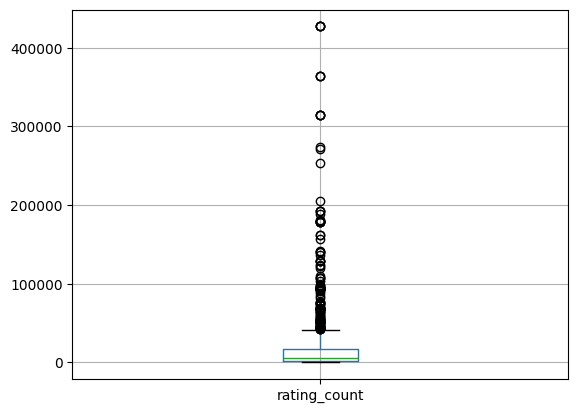

In [24]:
Amazon_df.boxplot(column='rating_count')
plt.show()

In [25]:
# Find missing values in rating count column
Amazon_df['rating_count'] = Amazon_df['rating_count'].fillna(Amazon_df['rating_count'].median())

In [26]:
print(f"The number of NaNs is: {Amazon_df.isna().sum().sum()}") 

The number of NaNs is: 0


#### 2.6) Find Duplications 

##### Removing duplicates is one of the most important part of the data wrangling process, we must remove the duplicates in order to get the correct insights from the data.¶
##### 

In [27]:
print(f"The number of duplication is: {Amazon_df.duplicated().sum()}")

The number of duplication is: 0


#### 2.7) Detect outliers

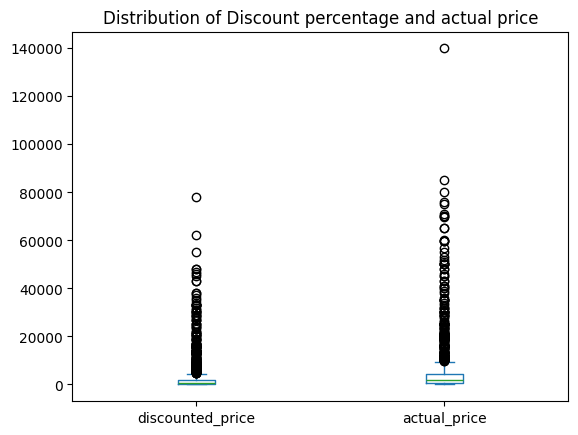

In [28]:
Amazon_df[["discounted_price","actual_price"]].plot(kind="box",title="Distribution of Discount percentage and actual price")
plt.show()

##### **Analysis Summary:**
##### ​Right-Skewed Distribution: The price data is heavily skewed to the right, meaning most products are low-priced.
##### ​Price Concentration: 75% of products are concentrated in the lower price range (below 5,000).
##### ​Extreme Outliers: Numerous outliers exist between 10,000 and 80,000, representing high-end electronics.
##### ​High Variance: There is a massive gap between the minimum and maximum prices, indicating a very diverse product catalog.

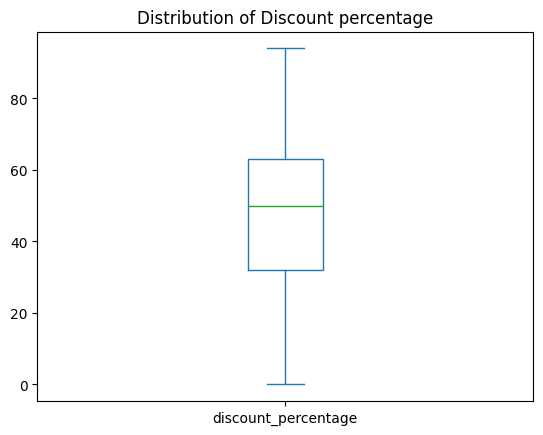

In [29]:
Amazon_df["discount_percentage"].plot(kind="box",title="Distribution of Discount percentage" )
plt.show()

##### **Analysis Summary:**
##### The discount percentage shows a healthy distribution with no outliers. Most products receive a discount between 30% and 60%, with a median of approximately 50%, indicating a consistent pricing strategy across the platform.

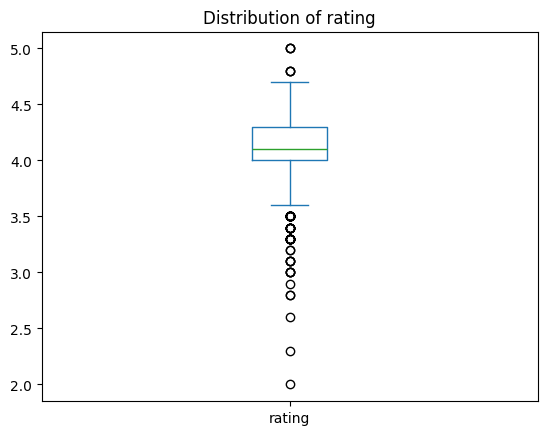

In [30]:
Amazon_df["rating"].plot(kind="box",title="Distribution of rating")
plt.show()

##### **Analysis Summary:**
##### The rating distribution shows high customer satisfaction with a median of 4.1. However, the bottom outliers highlight a small group of poorly rated products that require further investigation to understand customer dissatisfaction.

#### 2.8) Sanity Checks

In [31]:
invalid_prices = Amazon_df[Amazon_df["discounted_price"] > Amazon_df["actual_price"]]
print("Rows with discounted_price > actual_price:", len(invalid_prices))

Rows with discounted_price > actual_price: 0


In [32]:
invalid_discounts = Amazon_df[(Amazon_df["discount_percentage"] < 0) & (Amazon_df["discount_percentage"] > 100)]
print("Invalid discount percentages:", len(invalid_discounts))

Invalid discount percentages: 0


In [33]:
invalid_ratings = Amazon_df[(Amazon_df["rating"] < 0) & (Amazon_df["rating"] > 5)]
print("Invalid ratings:", len(invalid_ratings))

Invalid ratings: 0


### **3) Data Analysis**

#### 3.1) KPIs

In [34]:
KPIs={"Total Product": Amazon_df["product_id"].count(),
      "Average Discount Price" : Amazon_df["discounted_price"].median(),
      "Average Discount Rate" :Amazon_df["discount_percentage"].mean(),
            "Average Actual Price":Amazon_df["actual_price"].median(),
      "Average Rating " : Amazon_df["rating"].mean(),
      "Max Discount Percentage": Amazon_df["discount_percentage"].max(),
      "Min Discount Percentage": Amazon_df["discount_percentage"].min(),
     }
print(pd.DataFrame.from_dict(KPIs, orient="index", columns=["Value"]))

                               Value
Total Product            1465.000000
Average Discount Price    799.000000
Average Discount Rate      47.691468
Average Actual Price     1650.000000
Average Rating              4.096451
Max Discount Percentage    94.000000
Min Discount Percentage     0.000000


#### 3.2) Visualization

##### 1.1) Is the inventory dominated by budget or luxury items? 
##### 1.2) What is the typical discount strategy used by amazon? 
##### 1.3) Do customers generally give high or low ratings to these products?

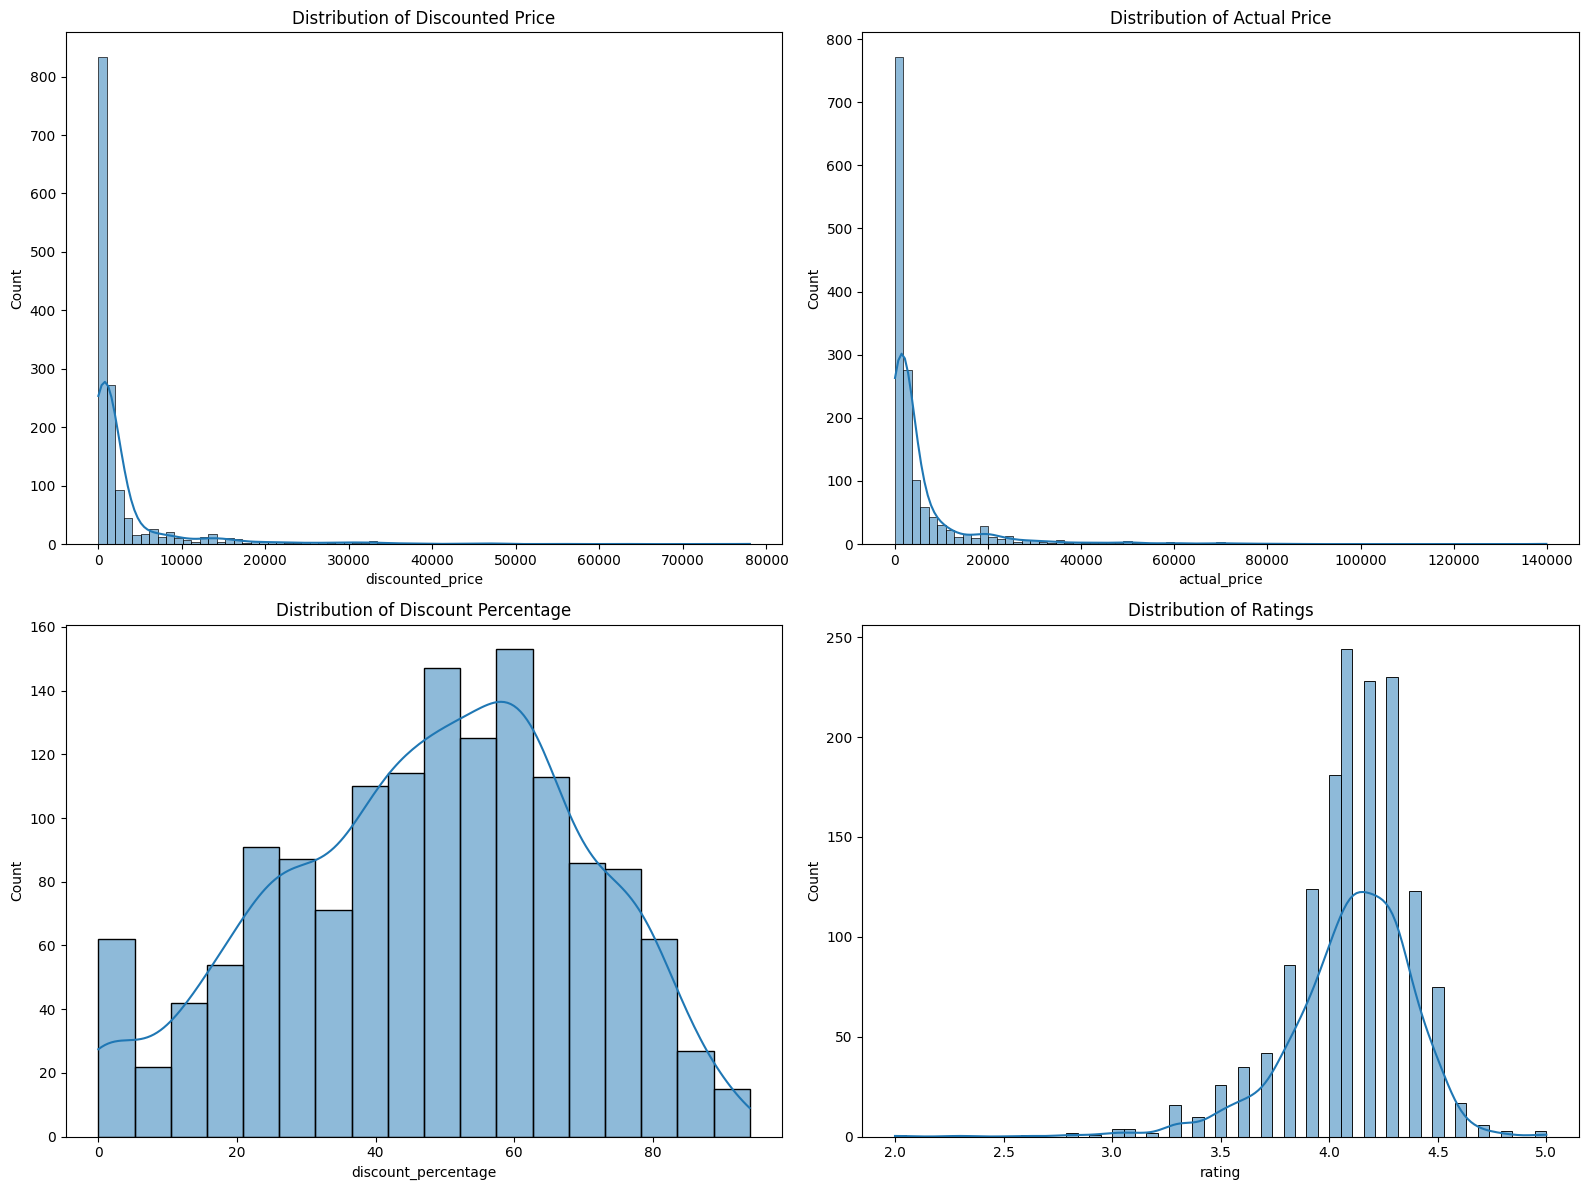

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(Amazon_df['discounted_price'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribution of Discounted Price")

sns.histplot(Amazon_df['actual_price'], kde=True, ax=axes[0,1])
axes[0,1].set_title("Distribution of Actual Price")

sns.histplot(Amazon_df['discount_percentage'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Distribution of Discount Percentage")

sns.histplot(Amazon_df['rating'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Distribution of Ratings")

plt.tight_layout()
plt.show()

##### 2) Which products generate the highest revenue?

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22052\2523282108.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_per_product.values, y=revenue_per_product.index, palette="viridis")


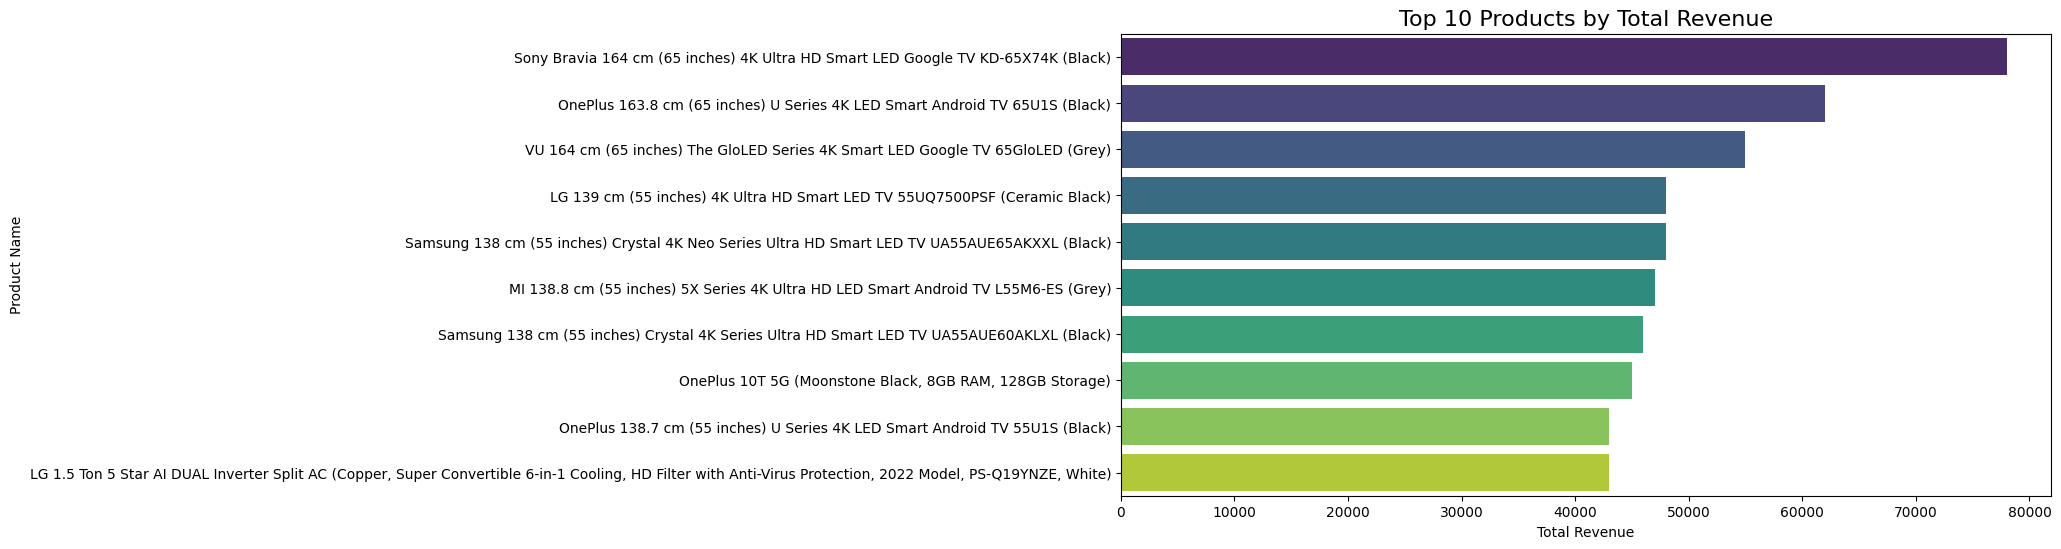

In [53]:
# Calculate total revenue per product
revenue_per_product =Amazon_df.groupby('product_name')['discounted_price'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=revenue_per_product.values, y=revenue_per_product.index, palette="viridis")
plt.title('Top 10 Products by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.show()

##### 3) Which products have the highest number of reviews and ratings?¶

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22052\2697991021.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratings_per_product.values, y=ratings_per_product.index, palette="magma")


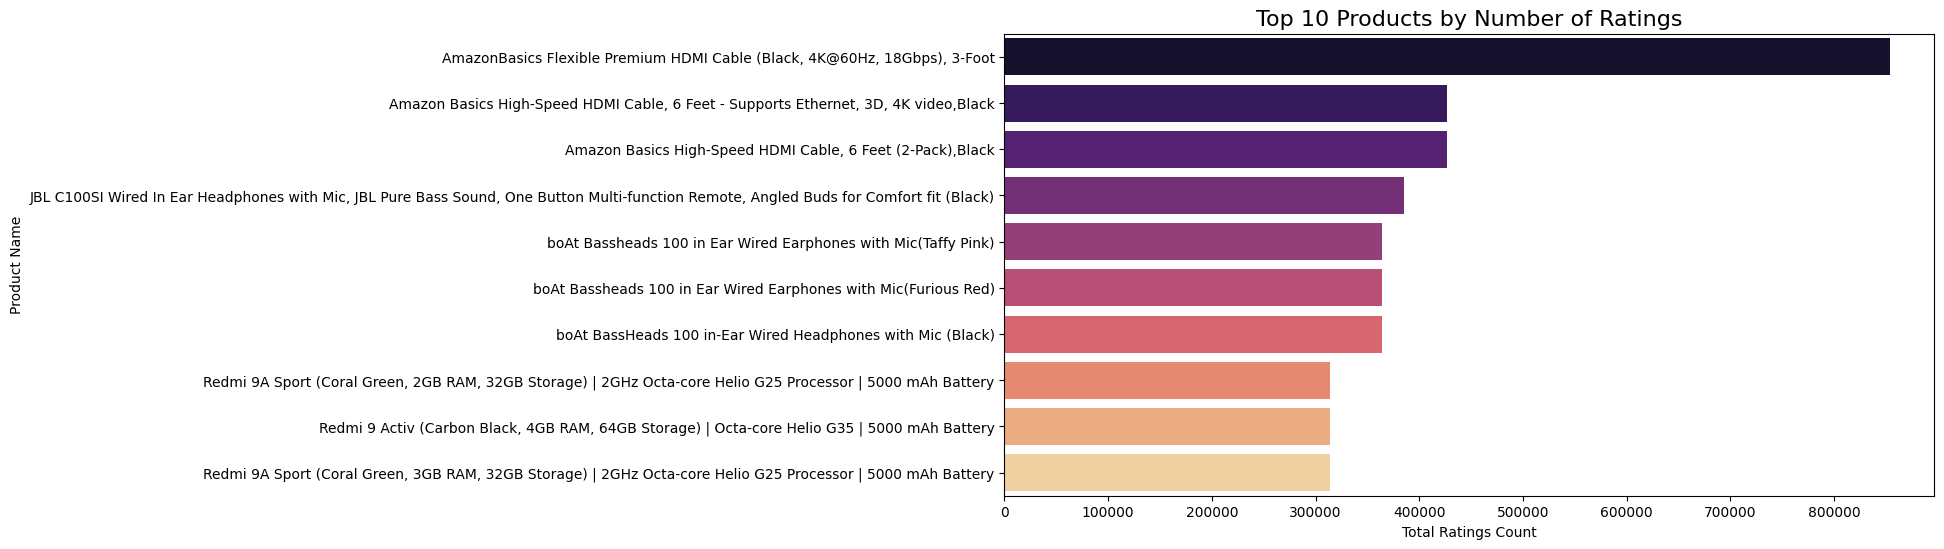

In [37]:
# Total ratings per product
ratings_per_product = Amazon_df.groupby('product_name')['rating_count'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=ratings_per_product.values, y=ratings_per_product.index, palette="magma")
plt.title('Top 10 Products by Number of Ratings', fontsize=16)
plt.xlabel('Total Ratings Count')
plt.ylabel('Product Name')
plt.show()

##### 4) Which products have low sales despite high ratings?¶


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22052\840501595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=low_sales_high_rating.values, y=low_sales_high_rating.index, palette="coolwarm")


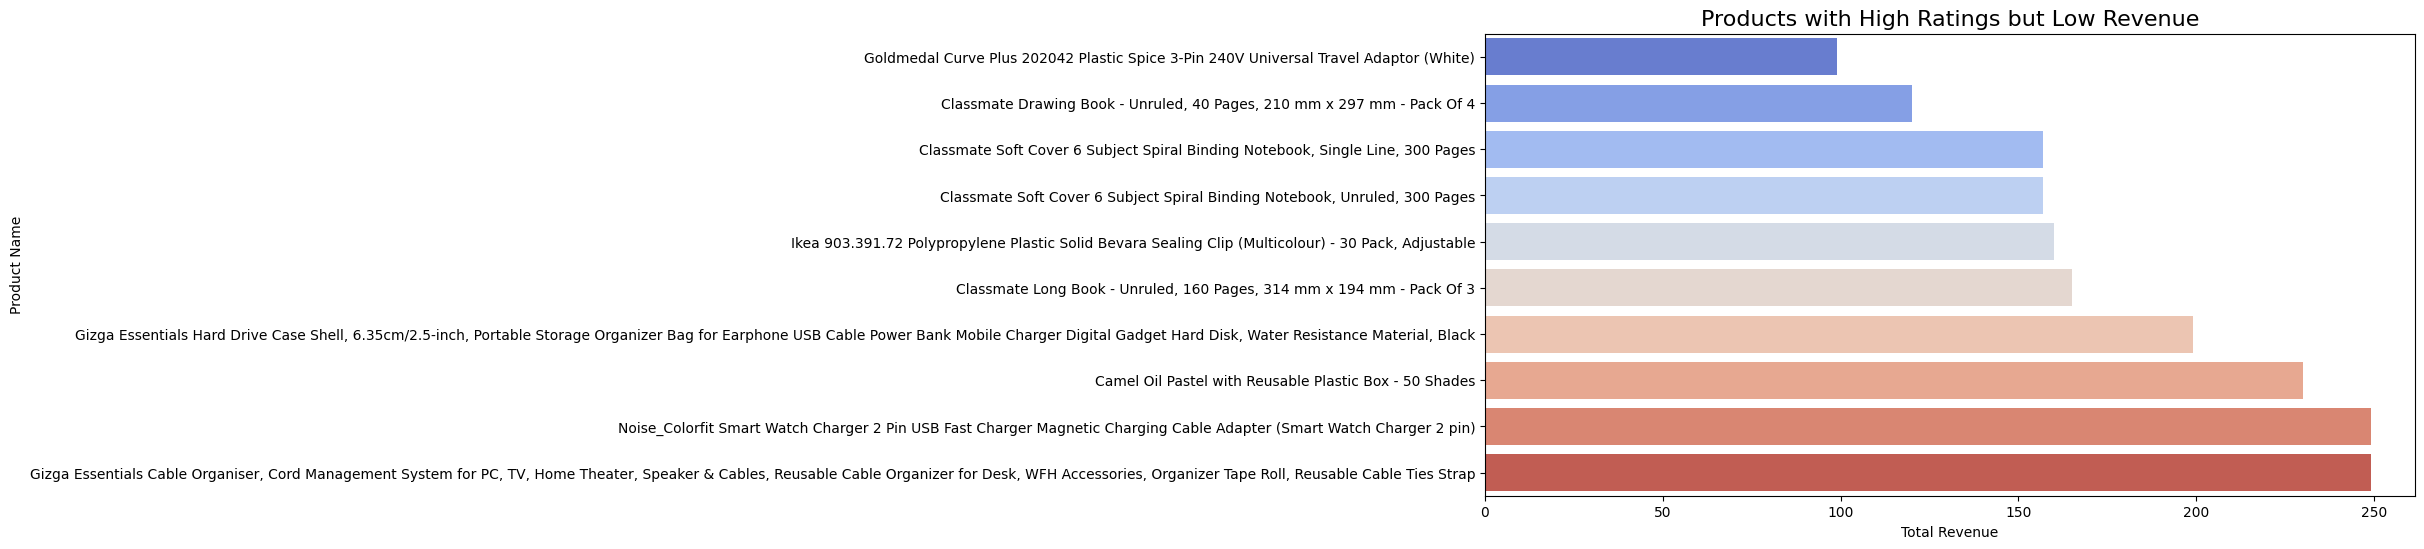

In [38]:
# High rated products
high_rating =Amazon_df[Amazon_df['rating'] >= 4.5]

# Aggregate revenue
low_sales_high_rating = high_rating.groupby('product_name')['discounted_price'].sum().sort_values().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=low_sales_high_rating.values, y=low_sales_high_rating.index, palette="coolwarm")
plt.title('Products with High Ratings but Low Revenue', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.show()

##### 5) Are there products with high discounts but low sales?¶

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22052\146288120.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_discount_low_sales.values, y=high_discount_low_sales.index, palette="rocket")


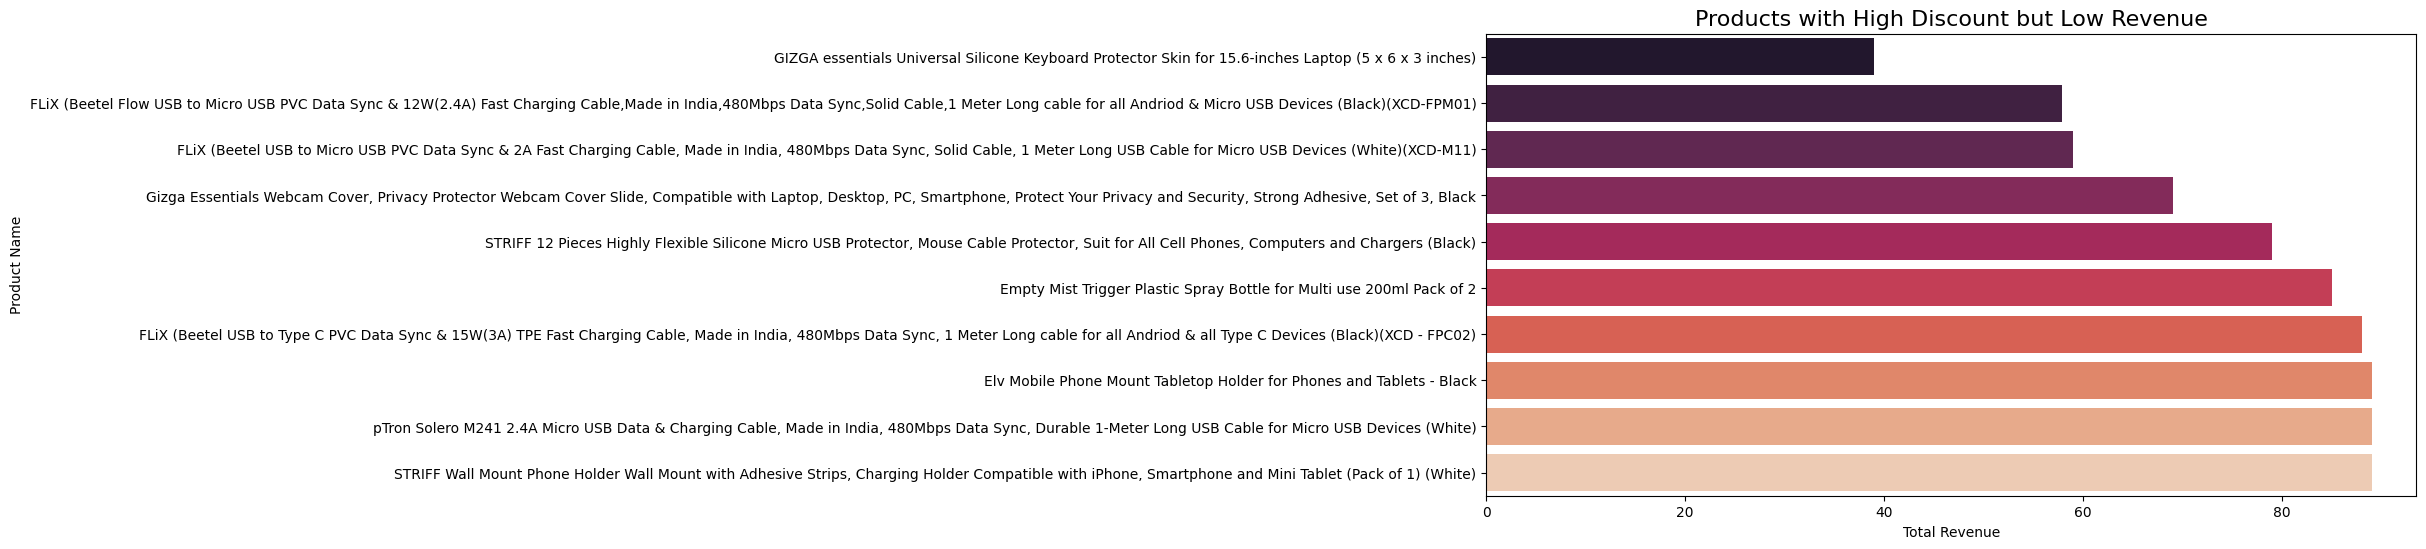

In [39]:
# Products with high discount (>50%) but low revenue
high_discount_low_sales = Amazon_df[(Amazon_df['discount_percentage'] > 50)]
high_discount_low_sales = high_discount_low_sales.groupby('product_name')['discounted_price'].sum().sort_values().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=high_discount_low_sales.values, y=high_discount_low_sales.index, palette="rocket")
plt.title('Products with High Discount but Low Revenue', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('Product Name')
plt.show()


##### 6) Which product categories are performing best vs worst?¶

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_22052\127979547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values,y=top_categories.index,palette="cubehelix")


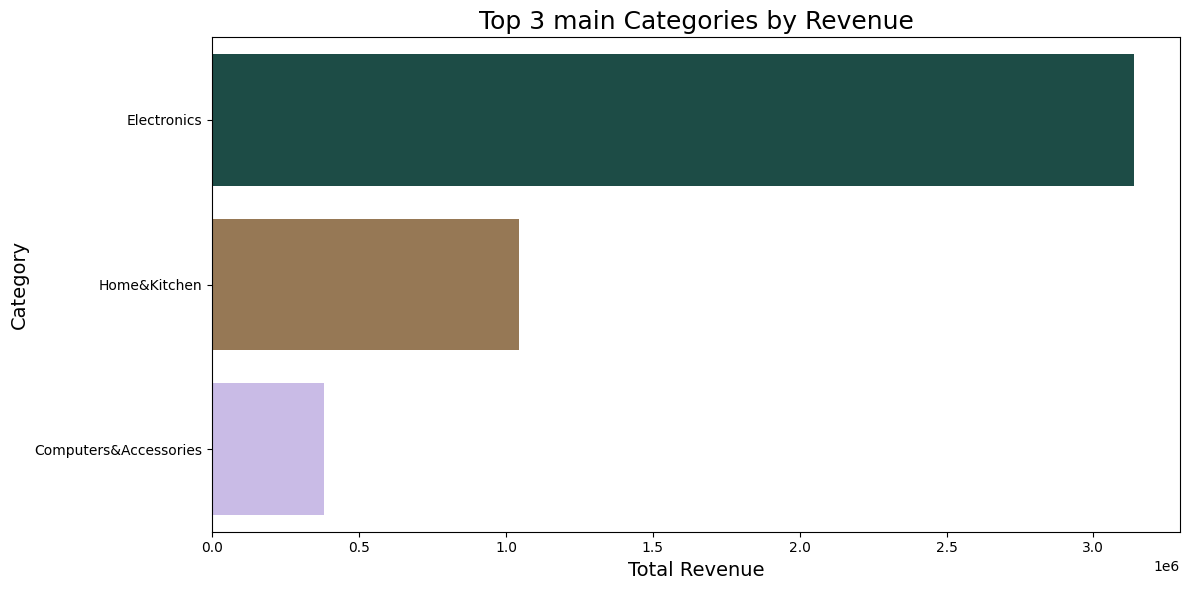

In [40]:
revenue_per_category = Amazon_df.groupby('main_category')['discounted_price'].sum().sort_values(ascending=False)
top_categories = revenue_per_category.head(3)

plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.values,y=top_categories.index,palette="cubehelix")
plt.title('Top 3 main Categories by Revenue', fontsize=18)
plt.xlabel('Total Revenue', fontsize=14)
plt.ylabel('Category', fontsize=14)
plt.tight_layout()
plt.show()

##### 7) Is there a correlation between the product price and its customer rating?¶

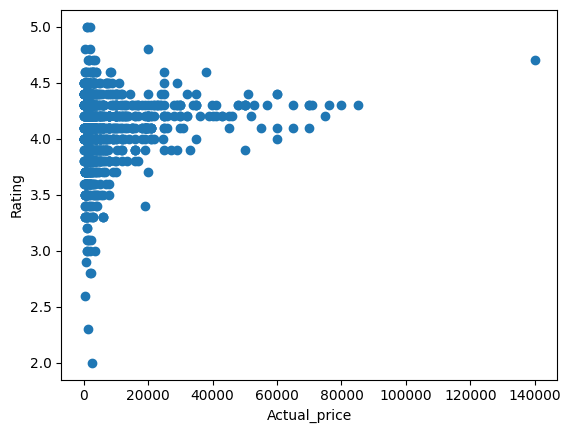

In [41]:
# Plot actual_price vs. rating
plt.scatter(Amazon_df['actual_price'], Amazon_df['rating'])
plt.xlabel('Actual_price')
plt.ylabel('Rating')
plt.show()

##### The scatter plot shows no strong linear correlation between price and rating. However, we observe that high-priced products tend to have more stable ratings (around 4.0-4.5), while low-priced products show much higher variance in customer satisfaction."

### **Summery¶**
#### **Price Distribution (Discounted & Actual)**¶
#### Both price variables show a right-skewed distribution.
#### The majority of products are in the low to mid-price range.
#### **Discount Percentage**
#### Discount percentages vary, but most fall between 40% and 70%.
### This suggests Amazon frequently offers large discounts to attract buyers.
####  **Rating Distribution**
#### Most ratings are between 3.5 and 4.5 stars, with a visible peak near 4.0.
#### Reflects high customer satisfaction and good product quality.
#### Only a small number of products have ratings below 3.
#### **Share of Products by Rating**
#### Nearly 95% of products hold ratings around 4 stars or above.
#### Indicates that the dataset is dominated by positive reviews.
#### **Count of Products by Exact Rating**
#### The most ratings above 4
#### Few products have neutral or low ratings, showing strong seller reputation and customer trust.




# **Thank You!**
### Thank you for reviewing this notebook.
### I hope the analysis and insights provided here help in making informed decisions regarding product performance, pricing, marketing, and operations.

### Your feedback and suggestions are always welcome! 